# Обратная задача для уравнения Вебстера

Ноутбук организован так, чтобы его можно было запускать сверху вниз:

1. настройки, стиль и целевой канал;
2. необязательный UNet для прямого восстановления профиля по карте `(H, f, x)`;
3. загрузка обученной прямой модели;
4. два обратных решателя: градиентный и метод Метрополиса;
5. сравнение решений;
6. дополнительные эксперименты включаются отдельными флагами.


In [ ]:
# Imports and plotting helpers

from pathlib import Path
import importlib

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

import vt_all_solvers_wrapper as vt
import dataset
import utils
import models.mlp as mlp_module
import models.fno as fno_module
import models.deep as deep_module
import models.back_base as back_base
import models.metropolis as metropolis_module
import models.inverse_unet as inverse_unet_module

importlib.reload(vt)
importlib.reload(dataset)
importlib.reload(utils)
importlib.reload(mlp_module)
importlib.reload(fno_module)
importlib.reload(deep_module)
importlib.reload(back_base)
importlib.reload(metropolis_module)
importlib.reload(inverse_unet_module)

import base_range_library 
importlib.reload(base_range_library)
from base_range_library import range_library

from dataset import StreamingGeometryDatasetConfig, make_streaming_dataloader
from models.mlp import ProfileMLP
from models.fno import TransferFunctionFNO
from models.deep import (
    TransferFunctionDeepONet,
    TransferFunctionMambaFusionDeepONet,
    TransferFunctionMambaOperator,
    TransferFunctionMambaSIRENDynamicDeformableDeepONet,
)
from models.back_base import InverseAreaSolver
from models.inverse_unet import (
    TransferMapInverseUNet,
    make_transfer_inverse_map,
    webster_inverse_unet_batch_to_xy,
)

# Shared plotting style for the inverse-solver notebook.
# Use the same diploma palette as the main forward notebook.
MAIN_COLORS = utils.apply_diploma_plot_style()
save_inverse_figures = True
inverse_figure_dir = Path("article/images")

# Role-based aliases, all taken from the main notebook palette.
INVERSE_COLORS = {
    "target": MAIN_COLORS["black"],
    "gradient": MAIN_COLORS["orange"],
    "metropolis": MAIN_COLORS["green"],
    "surrogate": MAIN_COLORS["grey"],
    "initial": MAIN_COLORS["grey"],
    "regularization": MAIN_COLORS["green"],
    "curvature": MAIN_COLORS["purple"],
}


def finish_inverse_figure(
    fig,
    filename_title: str,
    *,
    hide_titles: bool = False,
    save: bool | None = None,
):
    fig.tight_layout()
    should_save = save_inverse_figures if save is None else save
    if should_save:
        utils.save_figure(
            fig,
            filename_title=filename_title,
            output_dir=inverse_figure_dir,
            hide_titles=hide_titles,
            overwrite=True,
        )
    plt.show()
    plt.close(fig)


def set_inverse_axes(
    ax,
    *,
    xlabel: str,
    ylabel: str,
    title: str | None = None,
    legend: bool = True,
):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.22, linewidth=0.8)
    if legend:
        ax.legend(frameon=True, fontsize=9)


def plot_symmetric_radius(
    ax,
    x,
    area_series,
    *,
    labels,
    colors,
    linewidths=None,
    linestyles=None,
    alphas=None,
    zorders=None,
):
    n = len(area_series)
    if linewidths is None:
        linewidths = [2.0] * n
    if linestyles is None:
        linestyles = ["-"] * n
    if alphas is None:
        alphas = [1.0] * n
    if zorders is None:
        zorders = list(range(n, 0, -1))

    for area, label, color, linewidth, linestyle, alpha, zorder in zip(
        area_series,
        labels,
        colors,
        linewidths,
        linestyles,
        alphas,
        zorders,
    ):
        radius = np.sqrt(np.maximum(area, 0.0) / np.pi)
        ax.plot(
            x,
            radius,
            color=color,
            linewidth=linewidth,
            linestyle=linestyle,
            alpha=alpha,
            zorder=zorder,
            label=label,
        )
        ax.plot(
            x,
            -radius,
            color=color,
            linewidth=linewidth,
            linestyle=linestyle,
            alpha=alpha,
            zorder=zorder,
        )
    ax.axhline(0.0, color="0.25", linewidth=0.8, alpha=0.6, zorder=0)


In [ ]:
# Global configuration

device = "cuda" if torch.cuda.is_available() else "cpu"

# Available choices: "mlp", "fno", "deeponet", "mamba_fusion", "mamba_operator", "mamba_hybrid".
# The selected checkpoint must exist in checkpoints/.
model_choice = "mamba_hybrid"
mamba_hybrid_checkpoint_name = "mamba_siren_dynamic_deformable_deeponet_db"
# For the hole-finetuned version use:
# mamba_hybrid_checkpoint_name = "mamba_siren_dynamic_deformable_deeponet_hole_db"

sections = 100
n_profile_points = 128
n_frequencies = 256

f_min_hz = 50.0
f_max_hz = 5000.0

# Target sample generated by the classical cone solver.
target_geometry_kind = "random"
target_seed = 2028

# Inverse optimization parameters.
n_control_points = 10
n_inverse_steps = 5000
inverse_lr = 3e-3
log_every = 25

# Metropolis inverse parameters.
# Это второй тип обратного решения: стохастический поиск по контрольным точкам.
metropolis_n_steps = 6000
metropolis_burn_in = 1000
metropolis_thinning = 20
metropolis_proposal_std = 0.08
metropolis_temperature = 1.0

# Area bounds in physical units, m^2. Match base_range_library scale.
min_area_m2 = 1.0e-4
max_area_m2 = 5.0e-2

# Вес штрафа за первую производную log(area).
# Ограничивает общий наклон и слишком быстрые изменения площади вдоль канала.
# После деления конечной разности на dx величина smoothness возрастает,
# поэтому используется сравнительно небольшой коэффициент.
smoothness_weight = 1e-3

# Вес штрафа за вторую производную log(area).
# Подавляет локальные осцилляции, резкие изломы и "зубчатость" профиля.
# Вторая производная делится на dx**2, а затем возводится в квадрат,
# поэтому curvature имеет очень большой численный масштаб и требует
# значительно меньшего веса.
curvature_weight = 1e-8

# Вес отклонения найденного профиля от reference_area.
# Увеличивай этот вес, если профиль должен оставаться близким
# к среднему, начальному или другому известному допустимому профилю.
prior_weight = 0

# Optional long sections. Keep False for a clean top-to-bottom run.
run_inverse_unet_training = True
run_coarse_to_fine = False
run_find_hole = False

torch.manual_seed(1)

print("device:", device)
print("model_choice:", model_choice)


In [ ]:
# Solver configuration and target sample

solver_config = vt.SolverConfig(
    solver="cone",
    sections=sections,
    points=n_frequencies,
    f_min_hz=f_min_hz,
    f_max_hz=f_max_hz,
    grid="linear",
    beta_loss_np_per_m=0.0,
)

target_config = StreamingGeometryDatasetConfig(
    geometry_kind=target_geometry_kind,
    solver_config=solver_config,
    target_mode="db",
    seed=target_seed,
    max_samples=1,
)

target_loader = make_streaming_dataloader(
    target_config,
    range_library,
    batch_size=1,
    num_workers=0,
)

target_batch = next(iter(target_loader))

target_db = target_batch["target"].to(device).float()
frequencies_hz = target_batch["frequencies_hz"].to(device).float()

true_area_m2 = utils.make_webster_profile_features(
    target_batch,
    n_points=n_profile_points,
    log_area=False,
    include_x=False,
    channel_first=True,
    device=device,
)

print("target_db shape:", tuple(target_db.shape))
print("frequencies_hz shape:", tuple(frequencies_hz.shape))
print("true_area_m2 shape:", tuple(true_area_m2.shape))
print("target min/max dB:", float(target_db.min()), float(target_db.max()))


## UNet: восстановление профиля по карте `(H, f, x)`

Этот блок не участвует в градиентной обратной задаче. Он нужен как отдельная модель, которая напрямую предсказывает профиль канала по передаточной функции.


In [ ]:
# UNet input map visualization

inverse_unet_n_profile_points = n_profile_points
inverse_unet_target_log_area = True
inverse_unet_normalize_h = True
inverse_unet_map_mode = "prefix_solver"
inverse_unet_prefix_target_mode = "db"

map_batch = {
    "target": target_batch["target"][:1],
    "frequencies_hz": target_batch["frequencies_hz"][:1],
    "geometry": {
        key: value[:1] if hasattr(value, "__getitem__") else value
        for key, value in target_batch["geometry"].items()
    },
}
raw_inverse_map = make_transfer_inverse_map(
    map_batch,
    n_profile_points=inverse_unet_n_profile_points,
    map_mode=inverse_unet_map_mode,
    solver_config=solver_config,
    prefix_target_mode=inverse_unet_prefix_target_mode,
    normalize_h=False,
    include_frequency=True,
    include_x=True,
    device="cpu",
)
normalized_inverse_map = make_transfer_inverse_map(
    map_batch,
    n_profile_points=inverse_unet_n_profile_points,
    map_mode=inverse_unet_map_mode,
    solver_config=solver_config,
    prefix_target_mode=inverse_unet_prefix_target_mode,
    normalize_h=inverse_unet_normalize_h,
    include_frequency=True,
    include_x=True,
    device="cpu",
)

print("raw inverse map shape:", tuple(raw_inverse_map.shape))
print("normalized inverse map shape:", tuple(normalized_inverse_map.shape))

map_to_plot = raw_inverse_map[0].detach().cpu().numpy()
freq_to_plot = map_batch["frequencies_hz"][0].detach().cpu().numpy()
extent = [0.0, 1.0, float(freq_to_plot[0]), float(freq_to_plot[-1])]

fig, ax = plt.subplots(1, 1, figsize=(8.2, 5.0))
image = ax.imshow(
    map_to_plot[0],
    origin="lower",
    aspect="auto",
    extent=extent,
    cmap="magma",
)
ax.set_xlabel("нормированная координата")
ax.set_ylabel("частота, Гц")
ax.set_title("H([0, x], f), дБ")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
finish_inverse_figure(fig, "Обратная задача - карта входа UNet")


In [ ]:
# Train or load inverse UNet

run_inverse_unet_training = globals().get("run_inverse_unet_training", False)
inverse_unet_n_profile_points = globals().get("inverse_unet_n_profile_points", n_profile_points)
inverse_unet_target_log_area = globals().get("inverse_unet_target_log_area", True)
inverse_unet_normalize_h = globals().get("inverse_unet_normalize_h", True)
inverse_unet_map_mode = globals().get("inverse_unet_map_mode", "prefix_solver")
inverse_unet_prefix_target_mode = globals().get("inverse_unet_prefix_target_mode", "db")
inverse_unet_checkpoint_name = "inverse_unet_profile_db"
inverse_unet_checkpoint_path = Path("checkpoints") / f"{inverse_unet_checkpoint_name}_best.pt"

inverse_unet_batch_size = 2 if inverse_unet_map_mode == "prefix_solver" else 8
inverse_unet_epochs = 5
inverse_unet_steps_per_epoch = 20 if inverse_unet_map_mode == "prefix_solver" else 100
inverse_unet_val_steps = 4 if inverse_unet_map_mode == "prefix_solver" else 20
inverse_unet_lr = 1.0e-3
inverse_unet_weight_decay = 1.0e-4
inverse_unet_live_plot_every_steps = 1
inverse_unet_validation_metrics = {
    "MAE профиля": utils.mae_metric,
    "RMSE профиля": utils.rmse_metric,
    "относительная L2 профиля": utils.relative_l2_metric,
}

inverse_unet_train_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=310_000,
)

inverse_unet_val_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=410_000,
    max_samples=inverse_unet_batch_size * inverse_unet_val_steps,
)

inverse_unet_train_loader = make_streaming_dataloader(
    inverse_unet_train_config,
    range_library,
    batch_size=inverse_unet_batch_size,
    num_workers=0,
)

inverse_unet_val_loader = make_streaming_dataloader(
    inverse_unet_val_config,
    range_library,
    batch_size=inverse_unet_batch_size,
    num_workers=0,
)

inverse_unet_batch_to_xy = lambda batch, device: webster_inverse_unet_batch_to_xy(
    batch,
    device,
    n_profile_points=inverse_unet_n_profile_points,
    target_log_area=inverse_unet_target_log_area,
    map_mode=inverse_unet_map_mode,
    solver_config=solver_config,
    prefix_target_mode=inverse_unet_prefix_target_mode,
    normalize_h=inverse_unet_normalize_h,
    include_frequency=True,
    include_x=True,
)

inverse_unet = TransferMapInverseUNet(
    in_channels=3,
    out_channels=1,
    base_channels=24,
    channel_multipliers=(1, 2, 4, 8),
    bottleneck_multiplier=16,
    dropout=0.0,
    frequency_pool="meanmax",
).to(device)

print("inverse_unet parameters:", utils.count_parameters(inverse_unet))

inverse_unet_ready = False

if run_inverse_unet_training:
    inverse_unet_optimizer = utils.make_optimizer(
        inverse_unet,
        lr=inverse_unet_lr,
        weight_decay=inverse_unet_weight_decay,
    )

    inverse_unet_scheduler = utils.make_plateau_scheduler(
        inverse_unet_optimizer,
        factor=0.5,
        patience=3,
        min_lr=1.0e-6,
    )

    inverse_unet_history = utils.fit(
        inverse_unet,
        inverse_unet_optimizer,
        inverse_unet_train_loader,
        inverse_unet_val_loader,
        criterion=utils.mse_loss,
        batch_to_xy=inverse_unet_batch_to_xy,
        scheduler=inverse_unet_scheduler,
        config=utils.TrainConfig(
            epochs=inverse_unet_epochs,
            steps_per_epoch=inverse_unet_steps_per_epoch,
            val_steps=inverse_unet_val_steps,
            device=device,
            show_progress=False,
            live_plot_every_steps=inverse_unet_live_plot_every_steps,
            grad_clip_norm=1.0,
            checkpoint_name=inverse_unet_checkpoint_name,
            save_every_steps=None,
            validation_metrics=inverse_unet_validation_metrics,
            scheduler_on="val_loss",
        ),
    )
    utils.plot_history(inverse_unet_history)
    inverse_unet_ready = True
else:
    if inverse_unet_checkpoint_path.exists():
        inverse_unet_checkpoint = torch.load(
            inverse_unet_checkpoint_path,
            map_location=device,
            weights_only=False,
        )
        utils.load_model_state(
            inverse_unet,
            utils.checkpoint_state_dict(inverse_unet_checkpoint),
            strict=True,
        )
        inverse_unet_history = utils.checkpoint_history(inverse_unet_checkpoint)
        inverse_unet_ready = True
        print("loaded inverse UNet checkpoint:", inverse_unet_checkpoint_path)
    else:
        inverse_unet_history = None
        print("inverse UNet training skipped; checkpoint not found:", inverse_unet_checkpoint_path)


In [ ]:
# Preview inverse UNet profile reconstruction on a conical tube

if not globals().get("inverse_unet_ready", False):
    print(
        "inverse UNet is not trained/loaded yet. "
        "Set run_inverse_unet_training = True or provide checkpoint "
        f"{inverse_unet_checkpoint_path}"
    )
else:
    inverse_unet.eval()

    # Explicit conical tube sample for a controlled inverse-UNet check.
    # The same solver_config is used as in training/target generation.
    preview_geometry = vt.make_conical_geometry(
        length_m=1.0,
        area_in_m2=5.0e-4,
        area_out_m2=3.5e-3,
        sample_count=inverse_unet_n_profile_points,
    )
    preview_result = vt.solve(
        preview_geometry,
        config=solver_config,
    )
    preview_x_m, preview_area_m2, preview_segment_lengths = vt.geometry_to_tube_tuple(
        preview_geometry
    )

    preview_target_db = 20.0 * np.log10(
        np.maximum(np.asarray(preview_result.magnitude, dtype=np.float32), 1.0e-12)
    )

    inverse_unet_preview_batch = {
        "target": torch.tensor(preview_target_db, dtype=torch.float32).unsqueeze(0),
        "frequencies_hz": torch.tensor(
            preview_result.frequencies_hz,
            dtype=torch.float32,
        ).unsqueeze(0),
        "geometry": {
            "x_m": torch.tensor(preview_x_m, dtype=torch.float32).unsqueeze(0),
            "area_m2": torch.tensor(preview_area_m2, dtype=torch.float32).unsqueeze(0),
            "segment_lengths_m": torch.tensor(
                preview_segment_lengths,
                dtype=torch.float32,
            ).unsqueeze(0),
            "node_count": torch.tensor([len(preview_x_m)], dtype=torch.int64),
            "segment_count": torch.tensor([len(preview_segment_lengths)], dtype=torch.int64),
        },
    }

    inverse_unet_inputs, inverse_unet_target_profile = inverse_unet_batch_to_xy(
        inverse_unet_preview_batch,
        device,
    )

    with torch.inference_mode():
        inverse_unet_prediction = inverse_unet(inverse_unet_inputs)

    sample_idx = 0
    x_plot = np.linspace(0.0, 1.0, inverse_unet_n_profile_points)

    true_profile = inverse_unet_target_profile[sample_idx, 0].detach().cpu().numpy()
    predicted_profile = inverse_unet_prediction[sample_idx, 0].detach().cpu().numpy()

    if inverse_unet_target_log_area:
        true_area = np.exp(true_profile)
        predicted_area = np.exp(predicted_profile)
        y_label = "log(area)"
    else:
        true_area = true_profile
        predicted_area = predicted_profile
        y_label = "area, м²"

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

    axes[0].plot(
        x_plot,
        true_profile,
        color=INVERSE_COLORS["target"],
        linewidth=2.6,
        label="истинный конус",
    )
    axes[0].plot(
        x_plot,
        predicted_profile,
        color=INVERSE_COLORS["gradient"],
        linewidth=2.1,
        label="UNet",
    )
    set_inverse_axes(
        axes[0],
        xlabel="нормированная координата",
        ylabel=y_label,
        title="UNet на конусообразной трубе",
    )

    plot_symmetric_radius(
        axes[1],
        x_plot,
        [true_area, predicted_area],
        labels=["истинный конус", "UNet"],
        colors=[INVERSE_COLORS["target"], INVERSE_COLORS["gradient"]],
        linewidths=[2.6, 2.1],
        linestyles=["-", "-"],
        zorders=[2, 3],
    )
    set_inverse_axes(
        axes[1],
        xlabel="нормированная координата",
        ylabel="радиус, м",
        title="Симметричный профиль канала",
    )

    finish_inverse_figure(fig, "Обратная задача - UNet восстановление конуса")

    profile_mae = float(np.mean(np.abs(predicted_profile - true_profile)))
    area_rel_l2 = float(
        np.linalg.norm(predicted_area - true_area)
        / max(np.linalg.norm(true_area), 1.0e-12)
    )
    print("inverse UNet profile MAE on cone:", profile_mae)
    print("inverse UNet area relative L2 on cone:", area_rel_l2)


## UNet: четыре тестовые геометрии

Отдельный блок загружает сохраненные веса inverse UNet и сравнивает восстановленный профиль с истинным для четырех простых каналов: расширяющийся конус, сужающийся конус, прямая труба и трехточечная труба.


loaded inverse UNet checkpoint: checkpoints/inverse_unet_profile_db_best.pt
saved figure: article/images/обратная_задача_unet_четыре_геометрии.png


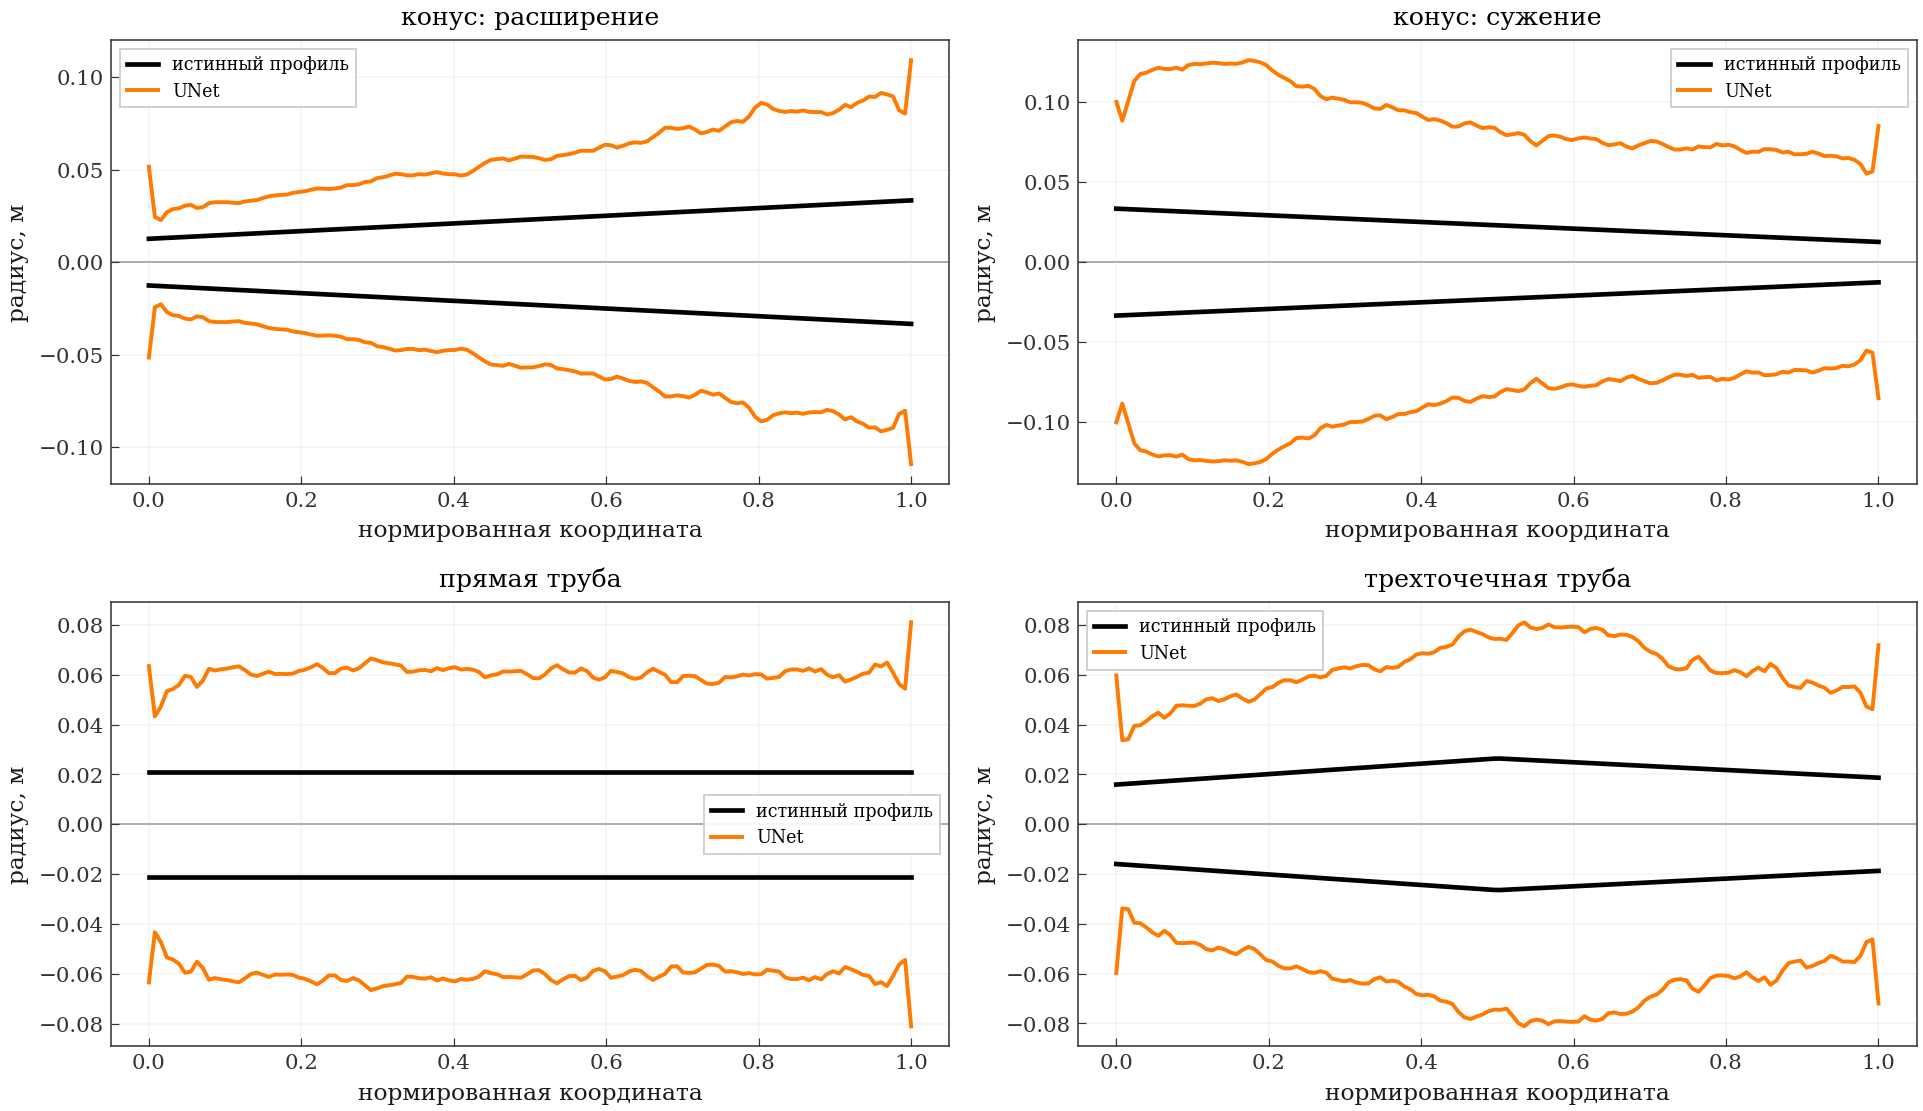

=== UNet на четырех тестовых геометриях ===
геометрия            |  MAE профиля |  area rel L2
----------------------------------------------------
конус: расширение    |      1.79218 |      5.94155
конус: сужение       |      2.73283 |      13.5972
прямая труба         |      2.10536 |      7.33052
трехточечная труба   |      2.07787 |      7.50536
saved figure: article/images/обратная_задача_unet_история_loss.png


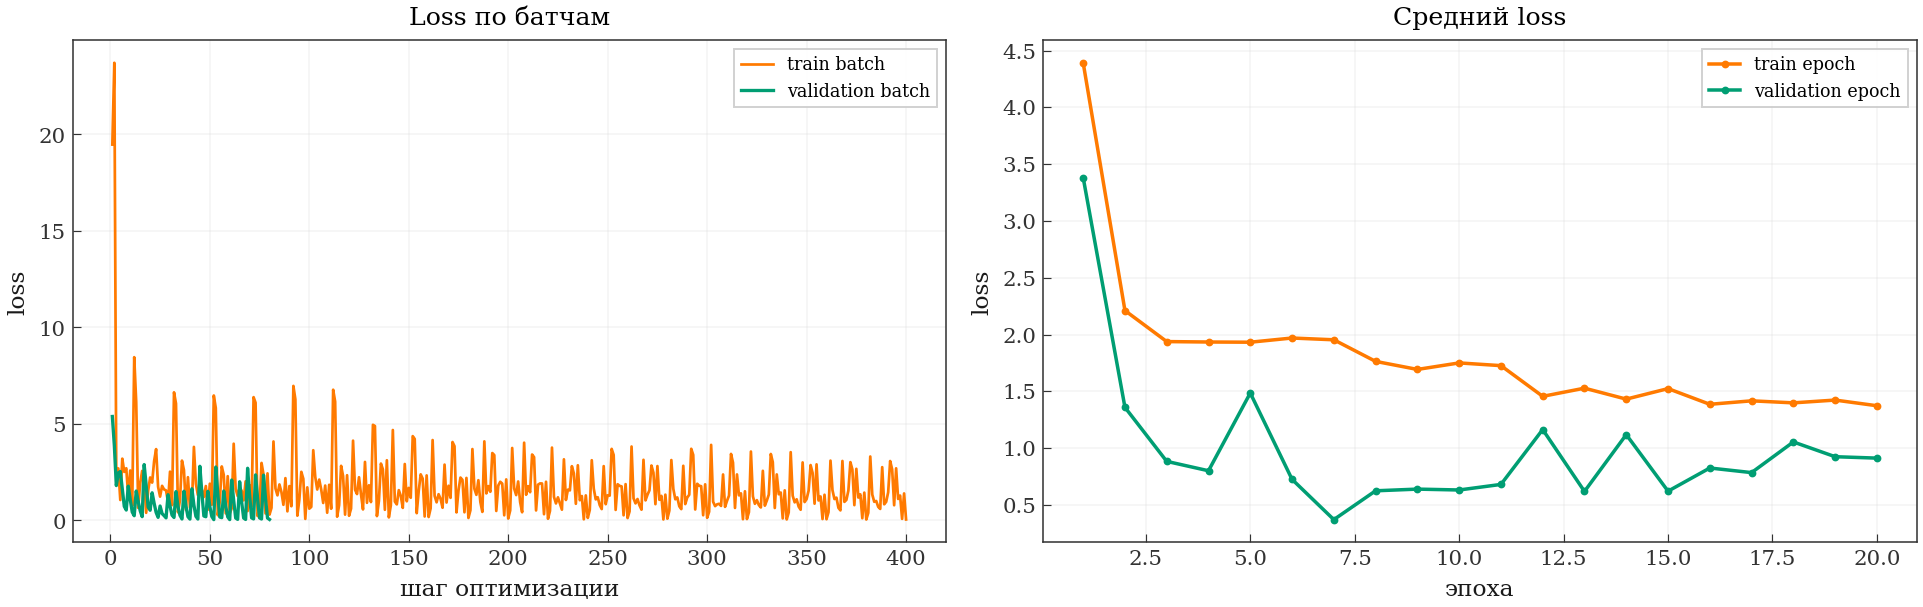

saved figure: article/images/обратная_задача_unet_история_метрик.png


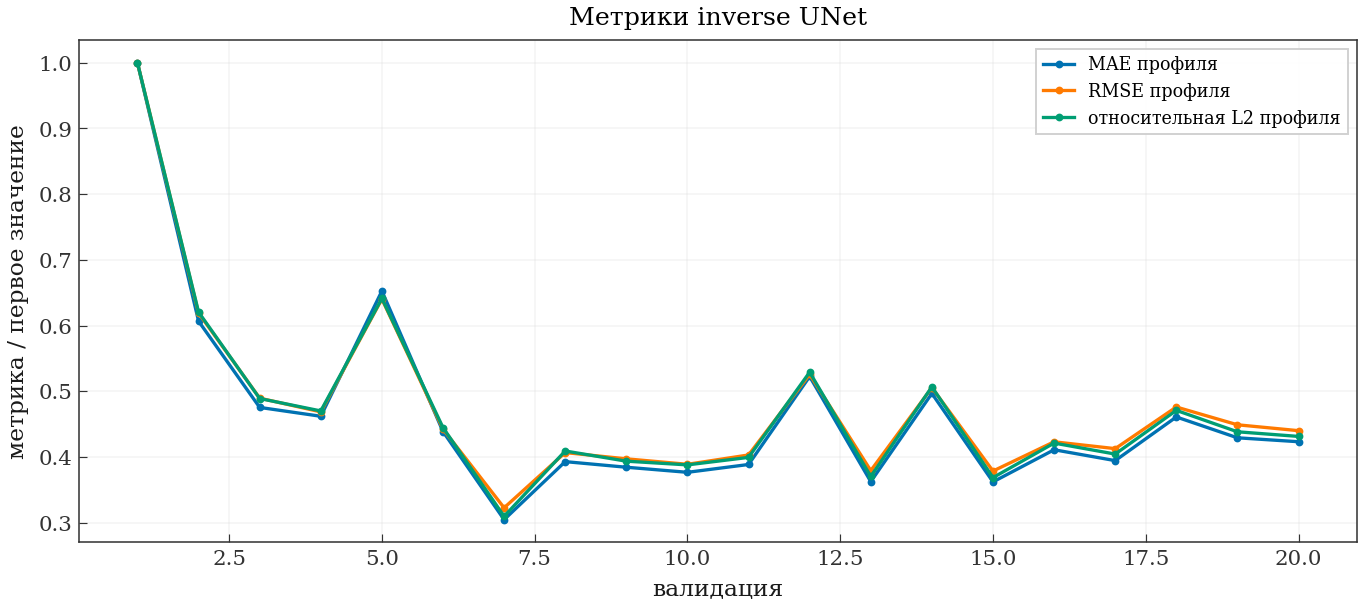

=== Лучшие значения метрик inverse UNet ===
MAE профиля: 0.504482
RMSE профиля: 0.580617
относительная L2 профиля: 0.137121


In [34]:
# Load inverse UNet checkpoint and compare four simple geometries

comparison_inverse_unet_checkpoint_name = "inverse_unet_profile_db"
comparison_inverse_unet_checkpoint_path = (
    Path("checkpoints") / f"{comparison_inverse_unet_checkpoint_name}_best.pt"
)

comparison_inverse_unet_n_profile_points = globals().get(
    "inverse_unet_n_profile_points",
    n_profile_points,
)
comparison_inverse_unet_target_log_area = globals().get(
    "inverse_unet_target_log_area",
    True,
)
comparison_inverse_unet_normalize_h = globals().get(
    "inverse_unet_normalize_h",
    True,
)
comparison_inverse_unet_map_mode = globals().get(
    "inverse_unet_map_mode",
    "prefix_solver",
)
comparison_inverse_unet_prefix_target_mode = globals().get(
    "inverse_unet_prefix_target_mode",
    "db",
)

comparison_inverse_unet = TransferMapInverseUNet(
    in_channels=3,
    out_channels=1,
    base_channels=24,
    channel_multipliers=(1, 2, 4, 8),
    bottleneck_multiplier=16,
    dropout=0.0,
    frequency_pool="meanmax",
).to(device)

if not comparison_inverse_unet_checkpoint_path.exists():
    raise FileNotFoundError(
        f"inverse UNet checkpoint not found: {comparison_inverse_unet_checkpoint_path}"
    )

comparison_inverse_unet_checkpoint = torch.load(
    comparison_inverse_unet_checkpoint_path,
    map_location=device,
    weights_only=False,
)
utils.load_model_state(
    comparison_inverse_unet,
    utils.checkpoint_state_dict(comparison_inverse_unet_checkpoint),
    strict=True,
)
comparison_inverse_unet.eval()
print("loaded inverse UNet checkpoint:", comparison_inverse_unet_checkpoint_path)

comparison_geometries = {
    "конус: расширение": vt.make_conical_geometry(
        length_m=1.0,
        area_in_m2=5.0e-4,
        area_out_m2=3.5e-3,
        sample_count=comparison_inverse_unet_n_profile_points,
    ),
    "конус: сужение": vt.make_conical_geometry(
        length_m=1.0,
        area_in_m2=3.5e-3,
        area_out_m2=5.0e-4,
        sample_count=comparison_inverse_unet_n_profile_points,
    ),
    "прямая труба": vt.make_cylinder_geometry(
        length_m=1.0,
        area_m2=1.4e-3,
    ),
    "трехточечная труба": vt.make_three_point_geometry(
        length_m=1.0,
        area_left_m2=8.0e-4,
        area_middle_m2=2.2e-3,
        area_right_m2=1.1e-3,
    ),
}


def make_single_geometry_batch(geometry):
    result = vt.solve(
        geometry,
        config=solver_config,
    )
    x_m, area_m2, segment_lengths_m = vt.geometry_to_tube_tuple(geometry)
    target_db = 20.0 * np.log10(
        np.maximum(np.asarray(result.magnitude, dtype=np.float32), 1.0e-12)
    )
    return {
        "target": torch.tensor(target_db, dtype=torch.float32).unsqueeze(0),
        "frequencies_hz": torch.tensor(
            result.frequencies_hz,
            dtype=torch.float32,
        ).unsqueeze(0),
        "geometry": {
            "x_m": torch.tensor(x_m, dtype=torch.float32).unsqueeze(0),
            "area_m2": torch.tensor(area_m2, dtype=torch.float32).unsqueeze(0),
            "segment_lengths_m": torch.tensor(
                segment_lengths_m,
                dtype=torch.float32,
            ).unsqueeze(0),
            "node_count": torch.tensor([len(x_m)], dtype=torch.int64),
            "segment_count": torch.tensor([len(segment_lengths_m)], dtype=torch.int64),
        },
    }


fig, axes = plt.subplots(2, 2, figsize=(14, 8.2))
axes = axes.ravel()
x_plot = np.linspace(0.0, 1.0, comparison_inverse_unet_n_profile_points)
comparison_rows = []

for ax, (geometry_name, geometry) in zip(axes, comparison_geometries.items()):
    batch = make_single_geometry_batch(geometry)
    inputs, target_profile = webster_inverse_unet_batch_to_xy(
        batch,
        device,
        n_profile_points=comparison_inverse_unet_n_profile_points,
        target_log_area=comparison_inverse_unet_target_log_area,
        map_mode=comparison_inverse_unet_map_mode,
        solver_config=solver_config,
        prefix_target_mode=comparison_inverse_unet_prefix_target_mode,
        normalize_h=comparison_inverse_unet_normalize_h,
        include_frequency=True,
        include_x=True,
    )

    with torch.inference_mode():
        prediction = comparison_inverse_unet(inputs)

    true_profile = target_profile[0, 0].detach().cpu().numpy()
    predicted_profile = prediction[0, 0].detach().cpu().numpy()

    if comparison_inverse_unet_target_log_area:
        true_area = np.exp(true_profile)
        predicted_area = np.exp(predicted_profile)
    else:
        true_area = true_profile
        predicted_area = predicted_profile

    plot_symmetric_radius(
        ax,
        x_plot,
        [true_area, predicted_area],
        labels=["истинный профиль", "UNet"],
        colors=[INVERSE_COLORS["target"], INVERSE_COLORS["gradient"]],
        linewidths=[2.4, 2.0],
        linestyles=["-", "-"],
        zorders=[2, 3],
    )
    set_inverse_axes(
        ax,
        xlabel="нормированная координата",
        ylabel="радиус, м",
        title=geometry_name,
    )

    profile_mae = float(np.mean(np.abs(predicted_profile - true_profile)))
    area_rel_l2 = float(
        np.linalg.norm(predicted_area - true_area)
        / max(np.linalg.norm(true_area), 1.0e-12)
    )
    comparison_rows.append(
        {
            "geometry": geometry_name,
            "profile_mae": profile_mae,
            "area_rel_l2": area_rel_l2,
        }
    )

finish_inverse_figure(fig, "Обратная задача - UNet четыре геометрии")

print("=== UNet на четырех тестовых геометриях ===")
print(f"{'геометрия':20s} | {'MAE профиля':>12s} | {'area rel L2':>12s}")
print("-" * 52)
for row in comparison_rows:
    print(
        f"{row['geometry']:20s} | "
        f"{row['profile_mae']:12.6g} | "
        f"{row['area_rel_l2']:12.6g}"
    )


# Separate loss plot from the loaded inverse-UNet checkpoint history.
comparison_inverse_unet_history = utils.checkpoint_history(
    comparison_inverse_unet_checkpoint
)
comparison_inverse_unet_history_data = utils.history_to_mapping(
    comparison_inverse_unet_history
)


def finite_xy(values):
    values = np.asarray(values or [], dtype=float)
    if values.size == 0:
        return np.asarray([], dtype=int), np.asarray([], dtype=float)
    mask = np.isfinite(values)
    return np.arange(1, values.size + 1, dtype=int)[mask], values[mask]


step_train_x, step_train_y = finite_xy(
    comparison_inverse_unet_history_data.get("step_train_loss", [])
)
step_val_x, step_val_y = finite_xy(
    comparison_inverse_unet_history_data.get("step_val_loss", [])
)
epoch_train_x, epoch_train_y = finite_xy(
    comparison_inverse_unet_history_data.get("train_loss", [])
)
epoch_val_x, epoch_val_y = finite_xy(
    comparison_inverse_unet_history_data.get("val_loss", [])
)

if (
    len(step_train_y)
    or len(step_val_y)
    or len(epoch_train_y)
    or len(epoch_val_y)
):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

    if len(step_train_y):
        axes[0].plot(
            step_train_x,
            step_train_y,
            linewidth=1.4,
            color=INVERSE_COLORS["gradient"],
            label="train batch",
        )
    if len(step_val_y):
        axes[0].plot(
            step_val_x,
            step_val_y,
            linewidth=1.7,
            color=INVERSE_COLORS["metropolis"],
            label="validation batch",
        )
    set_inverse_axes(
        axes[0],
        xlabel="шаг оптимизации",
        ylabel="loss",
        title="Loss по батчам",
    )

    if len(epoch_train_y):
        axes[1].plot(
            epoch_train_x,
            epoch_train_y,
            marker="o",
            markersize=3.0,
            linewidth=1.8,
            color=INVERSE_COLORS["gradient"],
            label="train epoch",
        )
    if len(epoch_val_y):
        axes[1].plot(
            epoch_val_x,
            epoch_val_y,
            marker="o",
            markersize=3.0,
            linewidth=1.8,
            color=INVERSE_COLORS["metropolis"],
            label="validation epoch",
        )
    set_inverse_axes(
        axes[1],
        xlabel="эпоха",
        ylabel="loss",
        title="Средний loss",
    )

    finish_inverse_figure(fig, "Обратная задача - UNet история loss")
else:
    print("inverse UNet checkpoint history has no loss values")


# Separate metric plot from the loaded inverse-UNet checkpoint history.
comparison_inverse_unet_metrics = comparison_inverse_unet_history_data.get(
    "metrics",
    {},
) or {}

if comparison_inverse_unet_metrics:
    fig, ax = plt.subplots(figsize=(10, 4.6))
    plotted_metrics = []

    for metric_name, metric_values in comparison_inverse_unet_metrics.items():
        metric_x, metric_y = finite_xy(metric_values)
        if not len(metric_y):
            continue

        first_value = metric_y[0] if abs(metric_y[0]) > 1.0e-12 else 1.0
        normalized_metric_y = metric_y / first_value
        ax.plot(
            metric_x,
            normalized_metric_y,
            marker="o",
            markersize=3.0,
            linewidth=1.7,
            label=str(metric_name),
        )
        plotted_metrics.append((str(metric_name), float(np.nanmin(metric_y))))

    set_inverse_axes(
        ax,
        xlabel="валидация",
        ylabel="метрика / первое значение",
        title="Метрики inverse UNet",
    )
    finish_inverse_figure(fig, "Обратная задача - UNet история метрик")

    if plotted_metrics:
        print("=== Лучшие значения метрик inverse UNet ===")
        for metric_name, best_value in plotted_metrics:
            print(f"{metric_name}: {best_value:.6g}")
else:
    print("inverse UNet checkpoint history has no metrics")


In [33]:
# Forward surrogate factory and checkpoint loading

def load_training_checkpoint(model, checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(checkpoint_path)

    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        state_dict = checkpoint["model_state"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    utils.load_model_state(model, state_dict, strict=True)
    model.eval()
    return checkpoint


def make_model(model_choice):
    if model_choice == "mlp":
        model = ProfileMLP(
            n_profile_points=n_profile_points,
            in_channels=2,
            n_frequencies=n_frequencies,
            hidden_dim=512,
            depth=4,
            dropout=0.05,
            out_channels=1,
        ).to(device)
        checkpoint_path = Path("checkpoints/mlp_db_best.pt")
        model_kind = "mlp"
        return model, checkpoint_path, model_kind

    if model_choice == "fno":
        model = TransferFunctionFNO(
            n_modes=32,
            hidden_channels=96,
            latent_dim=256,
            pooling_bins=16,
            frequency_bands=16,
            out_channels=1,
        ).to(device)
        checkpoint_path = Path("checkpoints/fno_db_best.pt")
        model_kind = "operator"
        return model, checkpoint_path, model_kind

    if model_choice == "deeponet":
        model = TransferFunctionDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
        ).to(device)
        checkpoint_path = Path("checkpoints/deeponet_db_best.pt")
        model_kind = "operator"
        return model, checkpoint_path, model_kind

    if model_choice == "mamba_fusion":
        model = TransferFunctionMambaFusionDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
            mamba_backend="minimal_mamba2",
            mamba_depth=1,
            mamba_expansion=2,
            mamba_kernel_size=4,
            mamba_d_state=32,
            mamba_headdim=32,
            mamba_chunk_size=64,
            dropout=0.0,
            residual_dot=True,
        ).to(device)
        checkpoint_path = Path("checkpoints/mamba_fusion_deeponet_db_best.pt")
        model_kind = "operator"
        return model, checkpoint_path, model_kind

    if model_choice == "mamba_operator":
        model = TransferFunctionMambaOperator(
            in_channels=1,
            d_model=32,
            hidden_channels=64,
            frequency_bands=16,
            frequency_hidden_dim=128,
            mamba_backend="minimal_mamba2",
            mamba_depth=2,
            mamba_expansion=2,
            mamba_kernel_size=4,
            mamba_d_state=16,
            mamba_headdim=32,
            mamba_chunk_size=32,
            dropout=0.0,
            out_channels=1,
            frequency_chunk_size=8,
        ).to(device)
        checkpoint_path = Path("checkpoints/mamba_operator_db_best.pt")
        model_kind = "operator"
        return model, checkpoint_path, model_kind

    if model_choice == "mamba_hybrid":
        model = TransferFunctionMambaSIRENDynamicDeformableDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            trunk_hidden_dim=128,
            trunk_hidden_layers=3,
            first_omega_0=10.0,
            hidden_omega_0=10.0,
            out_channels=1,
            n_experts=4,
            routing_hidden_dim=32,
            temperature=1.0,
            max_offset=2.0,
            offset_hidden_channels=32,
            mamba_backend="minimal_mamba2",
            mamba_depth=1,
            mamba_expansion=2,
            mamba_kernel_size=4,
            mamba_d_state=32,
            mamba_headdim=32,
            mamba_chunk_size=64,
            dropout=0.0,
            residual_dot=True,
            warm_start_verbose=False,
        ).to(device)
        checkpoint_path = Path("checkpoints") / f"{mamba_hybrid_checkpoint_name}_best.pt"
        model_kind = "operator"
        return model, checkpoint_path, model_kind

    raise ValueError(
        "model_choice must be one of: "
        "'mlp', 'fno', 'deeponet', 'mamba_fusion', "
        "'mamba_operator', 'mamba_hybrid'"
    )


model, checkpoint_path, model_kind = make_model(model_choice)
checkpoint = load_training_checkpoint(model, checkpoint_path)

print("loaded checkpoint:", checkpoint_path)
print("model_kind:", model_kind)
print("model parameters:", utils.count_parameters(model))


loaded checkpoint: checkpoints/mamba_siren_dynamic_deformable_deeponet_db_best.pt
model_kind: operator
model parameters: 938818


In [ ]:
# Quick forward check on the true geometry

with torch.inference_mode():
    if model_kind == "mlp":
        true_input = back_base.mlp_profile_input(
            true_area_m2,
            log_area=True,
            include_x=True,
        )
        surrogate_on_true = model(true_input)
    else:
        true_input = back_base.operator_area_input(
            true_area_m2,
            log_area=True,
        )
        kappa = back_base.make_kappa(
            frequencies_hz,
            f_min_hz=f_min_hz,
            f_max_hz=f_max_hz,
        )
        surrogate_on_true = model(true_input, kappa)

true_surrogate_mse = torch.mean((surrogate_on_true - target_db) ** 2)
print("surrogate(target geometry) MSE:", float(true_surrogate_mse))
print("surrogate output shape:", tuple(surrogate_on_true.shape))


## Базовый градиентный спуск

Детерминированный обратный решатель: параметры профиля площади оптимизируются градиентным спуском через замороженную прямую нейросетевую модель. Этот метод используется как базовая линия для сравнения с методом Метрополиса.


In [29]:
# Inverse optimization, method 1: baseline gradient descent

inverse_solver = InverseAreaSolver(
    model,
    model_kind=model_kind,
    log_area=True,
    include_x=True,
)

solution = inverse_solver.solve(
    target=target_db,
    frequencies_hz=frequencies_hz,
    n_points=n_profile_points,
    n_control_points=n_control_points,
    min_area_m2=min_area_m2,
    max_area_m2=max_area_m2,
    n_steps=n_inverse_steps,
    learning_rate=inverse_lr,
    smoothness_weight=smoothness_weight,
    curvature_weight=curvature_weight,
    prior_weight=prior_weight,
    gradient_clip_norm=10.0,
    log_every=log_every,
    f_min_hz=f_min_hz,
    f_max_hz=f_max_hz,
)

print("baseline gradient best total loss:", solution.total_loss)
print("baseline gradient best transfer loss:", solution.transfer_loss)
print("optimized area shape:", tuple(solution.area_m2.shape))

last_metrics = solution.history[-1]

print(
    "Inverse optimization metrics:\n"
    f"  total_loss:          {last_metrics['total_loss']:.6e}\n"
    f"  transfer_loss:       {last_metrics['transfer_loss']:.6e}\n"
    f"  weighted_smoothness: {last_metrics['weighted_smoothness']:.6e}\n"
    f"  weighted_curvature:  {last_metrics['weighted_curvature']:.6e}\n"
    f"  weighted_prior:      {last_metrics['weighted_prior']:.6e}"
)


baseline_gradient_solution = solution
gradient_solution = baseline_gradient_solution


baseline gradient best total loss: 23.21800994873047
baseline gradient best transfer loss: 22.60420036315918
optimized area shape: (1, 1, 128)
Inverse optimization metrics:
  total_loss:          2.321801e+01
  transfer_loss:       2.260420e+01
  weighted_smoothness: 5.513514e-01
  weighted_curvature:  6.245782e-02
  weighted_prior:      0.000000e+00


## Метод Метрополиса

Стохастический обратный решатель по тем же параметрам профиля. Используется как второй тип решения для сравнения с градиентной оптимизацией.


In [30]:
# Inverse optimization, method 2: metropolis

from models.metropolis import metropolis_inverse_for_project_model


def make_metropolis_profile_fn(
    *,
    n_points,
    min_area_m2,
    max_area_m2,
    fixed_inlet_area_m2=None,
    fixed_outlet_area_m2=None,
):
    def profile_fn(parameters):
        if parameters.ndim != 2:
            raise ValueError(
                "parameters must have shape [B, M], "
                f"got {tuple(parameters.shape)}"
            )

        control = min_area_m2 + (max_area_m2 - min_area_m2) * torch.sigmoid(
            parameters[:, None, :]
        )
        area = F.interpolate(
            control,
            size=n_points,
            mode="linear",
            align_corners=True,
        )

        if fixed_inlet_area_m2 is not None:
            inlet = torch.full_like(area[..., :1], float(fixed_inlet_area_m2))
            area = torch.cat([inlet, area[..., 1:]], dim=-1)

        if fixed_outlet_area_m2 is not None:
            outlet = torch.full_like(area[..., -1:], float(fixed_outlet_area_m2))
            area = torch.cat([area[..., :-1], outlet], dim=-1)

        return area

    return profile_fn


def area_to_initial_metropolis_parameters(
    area_m2,
    *,
    n_control_points,
    min_area_m2,
    max_area_m2,
):
    if area_m2.ndim == 2:
        area_m2 = area_m2.unsqueeze(1)
    if area_m2.ndim != 3:
        raise ValueError(
            "area_m2 must have shape [B, 1, Nx] or [B, Nx], "
            f"got {tuple(area_m2.shape)}"
        )

    control = F.interpolate(
        area_m2,
        size=n_control_points,
        mode="linear",
        align_corners=True,
    )
    normalized = (
        (control - min_area_m2)
        / (max_area_m2 - min_area_m2)
    ).clamp(1.0e-5, 1.0 - 1.0e-5)

    return torch.logit(normalized).squeeze(1)


metropolis_profile_fn = make_metropolis_profile_fn(
    n_points=n_profile_points,
    min_area_m2=min_area_m2,
    max_area_m2=max_area_m2,
)

# Start from the middle of the admissible area range.
# To start from the true/known initial profile, replace this with
# area_to_initial_metropolis_parameters(...).
metropolis_initial_parameters = torch.zeros(
    1,
    n_control_points,
    device=device,
)

metropolis_result = metropolis_inverse_for_project_model(
    model=model,
    target=target_db,
    frequencies_hz=frequencies_hz,
    initial_parameters=metropolis_initial_parameters,
    profile_fn=metropolis_profile_fn,
    transfer_loss_fn=back_base.transfer_mse_loss,
    model_kind=model_kind,
    log_area=True,
    include_x=True,
    f_min_hz=f_min_hz,
    f_max_hz=f_max_hz,
    n_steps=metropolis_n_steps,
    burn_in=metropolis_burn_in,
    thinning=metropolis_thinning,
    proposal_std=metropolis_proposal_std,
    temperature=metropolis_temperature,
)

print("metropolis best loss:", metropolis_result.best_loss)
print("metropolis accepted fraction:", metropolis_result.accepted_fraction)
print("metropolis samples shape:", tuple(metropolis_result.samples.shape))
print("metropolis best area shape:", tuple(metropolis_result.best_area.shape))
print("metropolis trace losses shape:", tuple(metropolis_result.trace_losses.shape))


metropolis best loss: 18.05284309387207
metropolis accepted fraction: 0.8978333333333334
metropolis samples shape: (250, 10)
metropolis best area shape: (1, 1, 128)


AttributeError: 'MetropolisResult' object has no attribute 'trace_losses'

In [ ]:
# Metropolis diagnostics

metropolis_trace_losses = metropolis_result.trace_losses.detach().cpu().numpy().reshape(-1)
metropolis_trace_steps = np.arange(1, len(metropolis_trace_losses) + 1)

metropolis_sample_losses = metropolis_result.losses.detach().cpu().numpy().reshape(-1)
metropolis_sample_steps = (
    metropolis_burn_in
    + 1
    + metropolis_thinning * np.arange(len(metropolis_sample_losses))
)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(
    metropolis_trace_steps,
    metropolis_trace_losses,
    linewidth=1.4,
    color=INVERSE_COLORS["metropolis"],
    alpha=0.9,
    label="loss на каждом шаге",
)
ax.scatter(
    metropolis_sample_steps,
    metropolis_sample_losses,
    s=14,
    color=INVERSE_COLORS["target"],
    alpha=0.75,
    label="сохраненные samples",
    zorder=3,
)
ax.axvline(
    metropolis_burn_in,
    color=INVERSE_COLORS["surrogate"],
    linewidth=1.2,
    linestyle="--",
    label="burn-in",
)
set_inverse_axes(
    ax,
    xlabel="шаг Метрополиса",
    ylabel="функция потерь",
    title="Диагностика метода Метрополиса",
)
finish_inverse_figure(fig, "Обратная задача - потери метода Метрополиса")


In [ ]:
# Gradient inverse diagnostics: loss curves

history = solution.history
steps = [row["step"] for row in history]

def hist(name):
    return [row[name] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

axes[0].plot(
    steps,
    hist("total_loss"),
    label="полная функция потерь",
    linewidth=2.0,
    color=INVERSE_COLORS["target"],
)
axes[0].plot(
    steps,
    hist("transfer_loss"),
    label="ошибка передаточной функции",
    linewidth=1.8,
    color=INVERSE_COLORS["gradient"],
)
set_inverse_axes(
    axes[0],
    xlabel="шаг оптимизации",
    ylabel="функция потерь",
    title="Градиентная оптимизация",
)

axes[1].plot(
    steps,
    hist("weighted_smoothness"),
    label="гладкость",
    linewidth=1.8,
)
axes[1].plot(
    steps,
    hist("weighted_curvature"),
    label="кривизна",
    linewidth=1.8,
)
axes[1].plot(
    steps,
    hist("weighted_prior"),
    label="априорный профиль",
    linewidth=1.8,
)
set_inverse_axes(
    axes[1],
    xlabel="шаг оптимизации",
    ylabel="взвешенная регуляризация",
    title="Регуляризация профиля",
)

finish_inverse_figure(fig, "Обратная задача - история градиентной оптимизации")


In [ ]:
# Gradient inverse diagnostics: transfer function

freq = frequencies_hz[0].detach().cpu().numpy()
target_np = target_db[0].detach().cpu().numpy()
pred_np = solution.prediction[0].detach().cpu().numpy()
true_surrogate_np = surrogate_on_true[0].detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(
    freq,
    target_np,
    linewidth=2.7,
    color=INVERSE_COLORS["target"],
    label="численное решение, дБ",
    zorder=4,
)
ax.plot(
    freq,
    pred_np,
    linewidth=2.0,
    color=INVERSE_COLORS["gradient"],
    label="базовый градиентный спуск",
    zorder=3,
)
ax.plot(
    freq,
    true_surrogate_np,
    linewidth=1.5,
    color=INVERSE_COLORS["surrogate"],
    linestyle="--",
    alpha=0.552,
    label="нейросеть на истинном профиле",
    zorder=2,
)
set_inverse_axes(
    ax,
    xlabel="частота, Гц",
    ylabel="передаточная функция, дБ",
    title="Градиентное решение: передаточная функция",
)
finish_inverse_figure(fig, "Обратная задача - градиентная передаточная функция")

mae = np.mean(np.abs(pred_np - target_np))
rmse = np.sqrt(np.mean((pred_np - target_np) ** 2))
print("inverse surrogate MAE dB:", float(mae))
print("inverse surrogate RMSE dB:", float(rmse))


In [ ]:
# Gradient inverse diagnostics: geometry

x = np.linspace(0.0, 1.0, n_profile_points)
true_area = true_area_m2[0, 0].detach().cpu().numpy()
opt_area = solution.area_m2[0, 0].detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

axes[0].plot(
    x,
    true_area,
    linewidth=2.6,
    color=INVERSE_COLORS["target"],
    label="истинный профиль",
    zorder=3,
)
axes[0].plot(
    x,
    opt_area,
    linewidth=2.0,
    color=INVERSE_COLORS["gradient"],
    linestyle="--",
    label="базовый градиентный спуск",
    zorder=4,
)
set_inverse_axes(
    axes[0],
    xlabel="нормированная координата",
    ylabel="площадь, м²",
    title="Профиль площади",
)

plot_symmetric_radius(
    axes[1],
    x,
    [true_area, opt_area],
    labels=["истинный профиль", "базовый градиентный спуск"],
    colors=[INVERSE_COLORS["target"], INVERSE_COLORS["gradient"]],
    linewidths=[2.6, 2.0],
    linestyles=["-", "--"],
    zorders=[3, 4],
)
set_inverse_axes(
    axes[1],
    xlabel="нормированная координата",
    ylabel="радиус, м",
    title="Симметричный вид канала",
)

finish_inverse_figure(fig, "Обратная задача - градиентная геометрия")

rel_area_l2 = np.linalg.norm(opt_area - true_area) / max(np.linalg.norm(true_area), 1e-12)
print("relative area L2:", float(rel_area_l2))


In [ ]:
# Optional validation by classical cone solver on optimized geometry

optimized_geometry = vt.ExplicitGeometry(
    x_m=x.tolist(),
    area_m2=opt_area.tolist(),
)

optimized_result = vt.solve(
    optimized_geometry,
    config=solver_config,
)

optimized_cone_db = 20.0 * np.log10(np.maximum(np.asarray(optimized_result.magnitude), 1e-12))

fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(
    freq,
    target_np,
    linewidth=2.7,
    color=INVERSE_COLORS["target"],
    label="цель: конический солвер",
    zorder=4,
)
ax.plot(
    freq,
    optimized_cone_db,
    linewidth=2.0,
    color=INVERSE_COLORS["gradient"],
    label="конический солвер на найденном профиле",
    zorder=3,
)
ax.plot(
    freq,
    pred_np,
    linewidth=1.5,
    color=INVERSE_COLORS["surrogate"],
    linestyle="--",
    alpha=0.55,
    label="предсказание нейросети",
    zorder=2,
)
set_inverse_axes(
    ax,
    xlabel="частота, Гц",
    ylabel="передаточная функция, дБ",
    title="Проверка найденной геометрии коническим солвером",
)
finish_inverse_figure(fig, "Обратная задача - проверка градиентной геометрии солвером")

mae_cone = np.mean(np.abs(optimized_cone_db - target_np))
rmse_cone = np.sqrt(np.mean((optimized_cone_db - target_np) ** 2))
print("cone validation MAE dB:", float(mae_cone))
print("cone validation RMSE dB:", float(rmse_cone))


## Сравнение двух обратных решений

Сравниваются геометрии и предсказания прямой нейросетевой модели на найденных профилях.


In [ ]:
# Comparison of inverse methods

freq = frequencies_hz[0].detach().cpu().numpy()
target_np = target_db[0].detach().cpu().numpy()
true_surrogate_np = surrogate_on_true[0].detach().cpu().numpy()

gradient_prediction_np = gradient_solution.prediction[0].detach().cpu().numpy()
metropolis_prediction_np = metropolis_result.best_prediction[0].detach().cpu().numpy()

true_area_np = true_area_m2[0, 0].detach().cpu().numpy()
gradient_area_np = gradient_solution.area_m2[0, 0].detach().cpu().numpy()
metropolis_area_np = metropolis_result.best_area[0, 0].detach().cpu().numpy()

x = np.linspace(0.0, 1.0, n_profile_points)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.0))

plot_symmetric_radius(
    axes[0],
    x,
    [true_area_np, gradient_area_np, metropolis_area_np],
    labels=["исходный профиль", "градиентный спуск", "метод Метрополиса"],
    colors=[
        INVERSE_COLORS["target"],
        INVERSE_COLORS["gradient"],
        INVERSE_COLORS["metropolis"],
    ],
    linewidths=[2.8, 2.2, 2.2],
    linestyles=["-", "-", "-"],
    zorders=[2, 4, 3],
)
set_inverse_axes(
    axes[0],
    xlabel="нормированная координата",
    ylabel="радиус, м",
    title="Симметричный профиль канала",
)

axes[1].plot(
    freq,
    true_surrogate_np,
    color=INVERSE_COLORS["target"],
    linewidth=2.6,
    label="нейросеть на исходном профиле",
    zorder=1,
)
axes[1].plot(
    freq,
    gradient_prediction_np,
    linewidth=2.1,
    color=INVERSE_COLORS["gradient"],
    label="нейросеть на профиле градиентного спуска",
    zorder=3,
)
set_inverse_axes(
    axes[1],
    xlabel="частота, Гц",
    ylabel="передаточная функция, дБ",
    title="Базовый градиентный спуск",
)

axes[2].plot(
    freq,
    true_surrogate_np,
    color=INVERSE_COLORS["target"],
    linewidth=2.6,
    label="нейросеть на исходном профиле",
    zorder=1,
)
axes[2].plot(
    freq,
    metropolis_prediction_np,
    linewidth=2.1,
    color=INVERSE_COLORS["metropolis"],
    label="нейросеть на профиле Метрополиса",
    zorder=3,
)
set_inverse_axes(
    axes[2],
    xlabel="частота, Гц",
    ylabel="передаточная функция, дБ",
    title="Метод Метрополиса",
)

finish_inverse_figure(fig, "Обратная задача - сравнение методов")


def prediction_metrics(prediction_np, target_np):
    return {
        "mae_db": float(np.mean(np.abs(prediction_np - target_np))),
        "rmse_db": float(np.sqrt(np.mean((prediction_np - target_np) ** 2))),
    }


def area_rel_l2(area_np, true_area_np):
    return float(
        np.linalg.norm(area_np - true_area_np)
        / max(np.linalg.norm(true_area_np), 1.0e-12)
    )

comparison_rows = [
    {
        "method": "градиентный спуск",
        **prediction_metrics(gradient_prediction_np, target_np),
        "area_rel_l2": area_rel_l2(gradient_area_np, true_area_np),
        "accepted_fraction": np.nan,
    },
    {
        "method": "Метрополис",
        **prediction_metrics(metropolis_prediction_np, target_np),
        "area_rel_l2": area_rel_l2(metropolis_area_np, true_area_np),
        "accepted_fraction": float(metropolis_result.accepted_fraction),
    },
]

print("=== Сравнение методов обратного решения ===")
print(f"{'method':12s} | {'MAE dB':>10s} | {'RMSE dB':>10s} | {'area rel L2':>12s} | {'accept':>8s}")
print("-" * 66)
for row in comparison_rows:
    accept = "-" if np.isnan(row["accepted_fraction"]) else f"{row['accepted_fraction']:.3f}"
    print(
        f"{row['method']:12s} | "
        f"{row['mae_db']:10.4f} | "
        f"{row['rmse_db']:10.4f} | "
        f"{row['area_rel_l2']:12.4f} | "
        f"{accept:>8s}"
    )


## Дополнительно: coarse-to-fine

Длинный эксперимент. Запускается только если `run_coarse_to_fine = True`.


In [ ]:
# Coarse-to-fine inverse optimization

if globals().get("run_coarse_to_fine", False):
    # Coarse-to-fine inverse optimization

    stages = [
        {
            "n_control_points": 4,
            "n_steps": 1500,
            "learning_rate": 3e-3,
            "smoothness_weight": 1e-4,
            "curvature_weight": 1e-8,
            "prior_weight": 0.0,
        },
        {
            "n_control_points": 8,
            "n_steps": 1500,
            "learning_rate": 2e-3,
            "smoothness_weight": 5e-5,
            "curvature_weight": 5e-9,
            "prior_weight": 0.0,
        },
        {
            "n_control_points": 16,
            "n_steps": 2000,
            "learning_rate": 1e-3,
            "smoothness_weight": 2e-5,
            "curvature_weight": 2e-9,
            "prior_weight": 0.0,
        },
    ]

    all_solutions = []
    initial_area_m2 = None

    for stage_idx, stage in enumerate(stages, start=1):
        print(f"\n=== Stage {stage_idx}: {stage['n_control_points']} control points ===")

        stage_solution = inverse_solver.solve(
            target=target_db,
            frequencies_hz=frequencies_hz,
            n_points=n_profile_points,
            n_control_points=stage["n_control_points"],
            min_area_m2=min_area_m2,
            max_area_m2=max_area_m2,
            initial_area_m2=initial_area_m2,
            n_steps=stage["n_steps"],
            learning_rate=stage["learning_rate"],
            smoothness_weight=stage["smoothness_weight"],
            curvature_weight=stage["curvature_weight"],
            prior_weight=stage["prior_weight"],
            gradient_clip_norm=10.0,
            log_every=log_every,
            f_min_hz=f_min_hz,
            f_max_hz=f_max_hz,
        )

        all_solutions.append(stage_solution)
        initial_area_m2 = stage_solution.area_m2.detach()

        last_metrics = stage_solution.history[-1]
        print(
            f"stage {stage_idx} done:\n"
            f"  total_loss:          {last_metrics['total_loss']:.6e}\n"
            f"  transfer_loss:       {last_metrics['transfer_loss']:.6e}\n"
            f"  weighted_smoothness: {last_metrics['weighted_smoothness']:.6e}\n"
            f"  weighted_curvature:  {last_metrics['weighted_curvature']:.6e}\n"
            f"  weighted_prior:      {last_metrics['weighted_prior']:.6e}"
        )

    coarse_solution = all_solutions[-1]
else:
    coarse_solution = None
    print("Coarse-to-fine skipped; set run_coarse_to_fine = True to run this section")


In [ ]:
# Coarse-to-fine diagnostics: transfer function

if globals().get("coarse_solution", None) is None:
    print("Coarse-to-fine result is not available; run the previous section first")
else:
    freq = frequencies_hz[0].detach().cpu().numpy()
    target_np = target_db[0].detach().cpu().numpy()
    pred_np = coarse_solution.prediction[0].detach().cpu().numpy()
    true_surrogate_np = surrogate_on_true[0].detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(12, 4.4))
    ax.plot(
        freq,
        target_np,
        linewidth=2.4,
        color=INVERSE_COLORS["target"],
        label="численное решение, дБ",
    )
    ax.plot(
        freq,
        pred_np,
        linewidth=2.0,
        color=INVERSE_COLORS["gradient"],
        label="восстановленный профиль",
    )
    ax.plot(
        freq,
        true_surrogate_np,
        linewidth=1.5,
        alpha=0.555,
        label="нейросеть на истинном профиле",
    )
    set_inverse_axes(
        ax,
        xlabel="частота, Гц",
        ylabel="передаточная функция, дБ",
        title="Coarse-to-fine: передаточная функция",
    )
    finish_inverse_figure(fig, "Обратная задача - coarse-to-fine передаточная функция")

    mae = np.mean(np.abs(pred_np - target_np))
    rmse = np.sqrt(np.mean((pred_np - target_np) ** 2))
    print("inverse surrogate MAE dB:", float(mae))
    print("inverse surrogate RMSE dB:", float(rmse))


In [ ]:
# Coarse-to-fine diagnostics: loss curves

if globals().get("coarse_solution", None) is None:
    print("Coarse-to-fine result is not available; run the previous section first")
else:
    history = coarse_solution.history
    steps = [row["step"] for row in history]

    def hist(name):
        return [row[name] for row in history]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

    axes[0].plot(steps, hist("total_loss"), label="полная функция потерь", linewidth=2.0, color=INVERSE_COLORS["target"])
    axes[0].plot(steps, hist("transfer_loss"), label="ошибка передаточной функции", linewidth=1.8, color=INVERSE_COLORS["gradient"])
    set_inverse_axes(
        axes[0],
        xlabel="шаг оптимизации",
        ylabel="функция потерь",
        title="Coarse-to-fine оптимизация",
    )

    axes[1].plot(steps, hist("weighted_smoothness"), label="гладкость", linewidth=1.8)
    axes[1].plot(steps, hist("weighted_curvature"), label="кривизна", linewidth=1.8)
    axes[1].plot(steps, hist("weighted_prior"), label="априорный профиль", linewidth=1.8)
    set_inverse_axes(
        axes[1],
        xlabel="шаг оптимизации",
        ylabel="взвешенная регуляризация",
        title="Регуляризация профиля",
    )

    finish_inverse_figure(fig, "Обратная задача - coarse-to-fine история")


In [ ]:
# Coarse-to-fine diagnostics: geometry

if globals().get("coarse_solution", None) is None:
    print("Coarse-to-fine result is not available; run the previous section first")
else:
    x = np.linspace(0.0, 1.0, n_profile_points)
    true_area = true_area_m2[0, 0].detach().cpu().numpy()
    opt_area = coarse_solution.area_m2[0, 0].detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

    axes[0].plot(x, true_area, linewidth=2.6, color=INVERSE_COLORS["target"], label="истинный профиль", zorder=3)
    axes[0].plot(x, opt_area, linewidth=2.0, color=INVERSE_COLORS["gradient"], linestyle="--", label="восстановленный профиль", zorder=4)
    set_inverse_axes(
        axes[0],
        xlabel="нормированная координата",
        ylabel="площадь, м²",
        title="Coarse-to-fine: профиль площади",
    )

    plot_symmetric_radius(
        axes[1],
        x,
        [true_area, opt_area],
        labels=["истинный профиль", "восстановленный профиль"],
        colors=[INVERSE_COLORS["target"], INVERSE_COLORS["gradient"]],
        linewidths=[2.6, 2.0],
        linestyles=["-", "--"],
        zorders=[3, 4],
    )
    set_inverse_axes(
        axes[1],
        xlabel="нормированная координата",
        ylabel="радиус, м",
        title="Симметричный вид канала",
    )

    finish_inverse_figure(fig, "Обратная задача - coarse-to-fine геометрия")

    rel_area_l2 = np.linalg.norm(opt_area - true_area) / max(np.linalg.norm(true_area), 1e-12)
    print("relative area L2:", float(rel_area_l2))


In [ ]:
# Coarse-to-fine validation by classical cone solver

if globals().get("coarse_solution", None) is None:
    print("Coarse-to-fine result is not available; run the previous section first")
else:
    # Optional validation by classical cone solver on optimized geometry

    optimized_geometry = vt.ExplicitGeometry(
        x_m=x.tolist(),
        area_m2=opt_area.tolist(),
    )

    optimized_result = vt.solve(
        optimized_geometry,
        config=solver_config,
    )

    optimized_cone_db = 20.0 * np.log10(np.maximum(np.asarray(optimized_result.magnitude), 1e-12))

    fig, ax = plt.subplots(figsize=(12, 4.4))
    ax.plot(freq, target_np, linewidth=2.4, color=INVERSE_COLORS["target"], label="цель: конический солвер")
    ax.plot(freq, optimized_cone_db, linewidth=2.0, color=INVERSE_COLORS["gradient"], label="конический солвер на найденном профиле")
    ax.plot(freq, pred_np, linewidth=1.4, alpha=0.555, label="предсказание нейросети")
    set_inverse_axes(
        ax,
        xlabel="частота, Гц",
        ylabel="передаточная функция, дБ",
        title="Coarse-to-fine: проверка коническим солвером",
    )
    finish_inverse_figure(fig, "Обратная задача - coarse-to-fine проверка солвером")

    mae_cone = np.mean(np.abs(optimized_cone_db - target_np))
    rmse_cone = np.sqrt(np.mean((optimized_cone_db - target_np) ** 2))
    print("cone validation MAE dB:", float(mae_cone))
    print("cone validation RMSE dB:", float(rmse_cone))


## Дополнительно: поиск дырки

Длинный эксперимент. Запускается только если `run_find_hole = True`.


In [ ]:
# Find a hole in a straight tube

if globals().get("run_find_hole", False):
    # Find a hole in a straight tube
    #
    # Goal:
    #   1. Create a target tube with a local hole / expansion.
    #   2. Create a straight tube with the same base area.
    #   3. Use the straight tube as initial_area_m2 for inverse optimization.
    #   4. Check whether the optimized geometry recovers the hole.

    hole_length_m = 1.0
    hole_base_width_m = 0.015
    hole_base_area_m2 = np.pi * (0.5 * hole_base_width_m) ** 2
    hole_center_m = 0.58

    # Use the project default hole geometry: hole_width_m, hole_height_m,
    # hole_area_gain_m2 and transition_width_m are intentionally not passed.
    # vt.make_tube_with_hole_geometry defines them relative to the tube itself.
    hole_geometry = vt.make_tube_with_hole_geometry(
        length_m=hole_length_m,
        base_width_m=hole_base_width_m,
        hole_center_m=hole_center_m,
    )

    straight_geometry = vt.make_cylinder_geometry(
        length_m=hole_length_m,
        area_m2=hole_base_area_m2,
    )


    def geometry_to_area_tensor(geometry, *, n_points, device):
        x_m, area_m2 = vt.geometry_to_arrays(geometry)
        batch = {
            "geometry": {
                "x_m": torch.tensor([x_m], dtype=torch.float32),
                "area_m2": torch.tensor([area_m2], dtype=torch.float32),
                "node_count": torch.tensor([len(x_m)], dtype=torch.int64),
            }
        }

        return utils.make_webster_profile_features(
            batch,
            n_points=n_points,
            log_area=False,
            include_x=False,
            channel_first=True,
            device=device,
        )


    hole_area_m2 = geometry_to_area_tensor(
        hole_geometry,
        n_points=n_profile_points,
        device=device,
    )

    straight_area_m2 = geometry_to_area_tensor(
        straight_geometry,
        n_points=n_profile_points,
        device=device,
    )

    hole_result = vt.solve(
        hole_geometry,
        config=solver_config,
    )

    hole_target_db_np = 20.0 * np.log10(
        np.maximum(np.asarray(hole_result.magnitude, dtype=np.float32), 1e-12)
    )

    hole_target_db = torch.tensor(
        hole_target_db_np,
        dtype=torch.float32,
        device=device,
    ).unsqueeze(0)

    hole_frequencies_hz = torch.tensor(
        hole_result.frequencies_hz,
        dtype=torch.float32,
        device=device,
    ).unsqueeze(0)

    print("hole target shape:", tuple(hole_target_db.shape))
    print("straight initial area shape:", tuple(straight_area_m2.shape))
    print("hole area min/max:", float(hole_area_m2.min()), float(hole_area_m2.max()))
    print("straight area:", float(straight_area_m2[0, 0, 0]))


    from losses import UniversalTransferFunctionLoss

    hole_super_loss = UniversalTransferFunctionLoss(
        output_type="db",
        db_weight=1.0,
        magnitude_weight=0.1,
        db_derivative_weight=0.05,
        peak_weight=0.0,
    )

    hole_frequencies_for_loss = hole_frequencies_hz[0].detach()

    def hole_inverse_super_loss(prediction, target):
        return hole_super_loss(
            prediction,
            target,
            hole_frequencies_for_loss,
        )


    inverse_solver = InverseAreaSolver(
        model,
        model_kind=model_kind,
        log_area=True,
        include_x=True,
        transfer_loss_fn=hole_inverse_super_loss,
    )



    # Quick sanity plot before inverse optimization.
    x_plot = np.linspace(0.0, 1.0, n_profile_points)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

    axes[0].plot(
        x_plot,
        hole_area_m2[0, 0].detach().cpu().numpy(),
        linewidth=2.4,
        color=INVERSE_COLORS["target"],
        label="труба с дыркой",
    )
    axes[0].plot(
        x_plot,
        straight_area_m2[0, 0].detach().cpu().numpy(),
        linewidth=2.0,
        color=INVERSE_COLORS["gradient"],
        label="начальная прямая труба",
    )
    set_inverse_axes(
        axes[0],
        xlabel="нормированная координата",
        ylabel="площадь, м²",
        title="Начальная геометрия поиска дырки",
    )

    axes[1].plot(
        hole_result.frequencies_hz,
        hole_target_db_np,
        linewidth=2.4,
        color=INVERSE_COLORS["target"],
        label="цель: конический солвер",
    )
    set_inverse_axes(
        axes[1],
        xlabel="частота, Гц",
        ylabel="передаточная функция, дБ",
        title="Целевая передаточная функция",
    )

    finish_inverse_figure(fig, "Обратная задача - поиск дырки начальные данные")

    # Coarse-to-fine helps because early stages cannot create high-frequency
    # oscillations in the profile. The straight tube is used as initialization
    # for stage 1; every next stage starts from the previous optimized profile.
    hole_stages = [
        # {
        #     "n_control_points": 4,
        #     "n_steps": 1500,
        #     "learning_rate": 3e-3,
        #     "smoothness_weight": 1e-4,
        #     "curvature_weight": 1e-8,
        #     "prior_weight": 0.0,
        #     "reference_area_m2": None,
        # },
        {
            "n_control_points": 10,
            "n_steps": 1500,
            "learning_rate": 2e-3,
            "smoothness_weight": 7e-5,
            "curvature_weight": 7e-9,
            "prior_weight": 0.0,
            "reference_area_m2": None,
        },
        {
            "n_control_points": 20,
            "n_steps": 2000,
            "learning_rate": 1e-3,
            "smoothness_weight": 5e-5,
            "curvature_weight": 5e-9,
            "prior_weight": 0.0,
            "reference_area_m2": None,
        },
        # {
        #     "n_control_points": 50,
        #     "n_steps": 2000,
        #     "learning_rate": 1e-3,
        #     "smoothness_weight": 5e-7,
        #     "curvature_weight": 5e-11,
        #     "prior_weight": 0.0,
        #     "reference_area_m2": None,
        # },
    ]

    hole_solutions = []
    initial_area_m2 = straight_area_m2.detach()

    for stage_idx, stage in enumerate(hole_stages, start=1):
        print(
            f"\n=== Find-hole stage {stage_idx}: "
            f"{stage['n_control_points']} control points ==="
        )

        hole_solution = inverse_solver.solve(
            target=hole_target_db,
            frequencies_hz=hole_frequencies_hz,
            n_points=n_profile_points,
            n_control_points=stage["n_control_points"],
            min_area_m2=min_area_m2,
            max_area_m2=max_area_m2,
            initial_area_m2=initial_area_m2,
            reference_area_m2=stage["reference_area_m2"],
            n_steps=stage["n_steps"],
            learning_rate=stage["learning_rate"],
            smoothness_weight=stage["smoothness_weight"],
            curvature_weight=stage["curvature_weight"],
            prior_weight=stage["prior_weight"],
            gradient_clip_norm=10.0,
            log_every=log_every,
            initialization_noise=0.05,
            f_min_hz=f_min_hz,
            f_max_hz=f_max_hz,
        )

        hole_solutions.append(hole_solution)
        initial_area_m2 = hole_solution.area_m2.detach()

        last_metrics = hole_solution.history[-1]
        print(
            "stage metrics:\n"
            f"  total_loss:          {last_metrics['total_loss']:.6e}\n"
            f"  transfer_loss:       {last_metrics['transfer_loss']:.6e}\n"
            f"  weighted_smoothness: {last_metrics['weighted_smoothness']:.6e}\n"
            f"  weighted_curvature:  {last_metrics['weighted_curvature']:.6e}\n"
            f"  weighted_prior:      {last_metrics['weighted_prior']:.6e}"
        )

    hole_solution = hole_solutions[-1]
    hole_optimized_area = hole_solution.area_m2[0, 0].detach().cpu().numpy()
    hole_prediction_db = hole_solution.prediction[0].detach().cpu().numpy()

    # Validate the optimized profile by running the classical cone solver on it.
    hole_optimized_geometry = vt.ExplicitGeometry(
        x_m=x_plot.tolist(),
        area_m2=hole_optimized_area.tolist(),
    )

    hole_optimized_cone_result = vt.solve(
        hole_optimized_geometry,
        config=solver_config,
    )

    hole_optimized_cone_db = 20.0 * np.log10(
        np.maximum(np.asarray(hole_optimized_cone_result.magnitude), 1e-12)
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

    true_hole_area = hole_area_m2[0, 0].detach().cpu().numpy()
    initial_straight_area = straight_area_m2[0, 0].detach().cpu().numpy()

    axes[0].plot(
        x_plot,
        true_hole_area,
        linewidth=2.4,
        color=INVERSE_COLORS["target"],
        label="труба с дыркой",
    )
    axes[0].plot(
        x_plot,
        initial_straight_area,
        linewidth=1.8,
        color=INVERSE_COLORS["initial"],
        label="начальная прямая труба",
    )
    axes[0].plot(
        x_plot,
        hole_optimized_area,
        linewidth=2.1,
        color=INVERSE_COLORS["gradient"],
        label="восстановленный профиль",
    )
    set_inverse_axes(
        axes[0],
        xlabel="нормированная координата",
        ylabel="площадь, м²",
        title="Восстановленная площадь",
    )

    plot_symmetric_radius(
        axes[1],
        x_plot,
        [true_hole_area, initial_straight_area, hole_optimized_area],
        labels=["труба с дыркой", "начальная прямая труба", "восстановленный профиль"],
        colors=[INVERSE_COLORS["target"], INVERSE_COLORS["initial"], INVERSE_COLORS["gradient"]],
        linewidths=[2.4, 1.7, 2.1],
    )
    set_inverse_axes(
        axes[1],
        xlabel="нормированная координата",
        ylabel="радиус, м",
        title="Симметричный вид канала",
    )

    axes[2].plot(
        hole_result.frequencies_hz,
        hole_target_db_np,
        linewidth=2.4,
        color=INVERSE_COLORS["target"],
        label="цель: конический солвер",
    )
    axes[2].plot(
        hole_result.frequencies_hz,
        hole_prediction_db,
        linewidth=2.0,
        color=INVERSE_COLORS["gradient"],
        label="предсказание нейросети",
    )
    axes[2].plot(
        hole_result.frequencies_hz,
        hole_optimized_cone_db,
        linewidth=1.6,
        alpha=0.558,
        label="конический солвер на найденном профиле",
    )
    set_inverse_axes(
        axes[2],
        xlabel="частота, Гц",
        ylabel="передаточная функция, дБ",
        title="Проверка передаточной функции",
    )

    finish_inverse_figure(fig, "Обратная задача - поиск дырки результат")

    hole_area_rel_l2 = np.linalg.norm(
        hole_optimized_area - hole_area_m2[0, 0].detach().cpu().numpy()
    ) / max(np.linalg.norm(hole_area_m2[0, 0].detach().cpu().numpy()), 1e-12)

    hole_surrogate_mae = np.mean(np.abs(hole_prediction_db - hole_target_db_np))
    hole_cone_mae = np.mean(np.abs(hole_optimized_cone_db - hole_target_db_np))

    print("find-hole relative area L2:", float(hole_area_rel_l2))
    print("find-hole surrogate MAE dB:", float(hole_surrogate_mae))
    print("find-hole cone validation MAE dB:", float(hole_cone_mae))
else:
    print("Find-a-hole skipped; set run_find_hole = True to run this section")
